In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MEE,FOLD_VL_MEE,FOLD_TR_MEE
from cross_common import MEE,MSE,RMSE,MAE


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ----- Defining model basic architecture --------
base_hidden_layers = ["64"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.7    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = early_stopping_patience - 20
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = trial_dict["batch_size"]
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])

    net_trial = nnc.build_mlp(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.MLP(net_trial, output_adapter_trial)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_MEE,
    fold_metric=FOLD_VL_MEE,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100,
        "batch_size": 64,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-03-19 12:41:00,124] A new study created in memory with name: no-name-09068c47-8f4d-4e9b-ae1a-82f51dbc065b
  5%|▌         | 1/20 [00:01<00:37,  1.98s/it]

[I 2026-03-19 12:41:02,113] Trial 0 finished with values: [24.305707035432103, 0.24396689058387133, 0.25294103954920794] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


 10%|█         | 2/20 [00:03<00:32,  1.81s/it]

[I 2026-03-19 12:41:03,806] Trial 1 finished with values: [25.522190028402225, 0.08682361860589466, 0.16278137311713292] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:05<00:29,  1.75s/it]

...

[I 2026-03-19 12:41:31,273] Trial 17 finished with values: [25.371424421633293, 0.15619676946648575, 0.2624022972472416] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:32<00:01,  1.70s/it]

[I 2026-03-19 12:41:32,995] Trial 18 finished with values: [24.384995649694762, 0.2747908311356716, 0.2737034672012954] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


100%|██████████| 20/20 [00:34<00:00,  1.73s/it]

[I 2026-03-19 12:41:34,785] Trial 19 finished with values: [25.323484667686348, 0.15326489859760262, 0.26577923186635655] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100,
        "batch_size": 64,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-03-19 12:41:34,858] A new study created in memory with name: no-name-63fce636-81dd-4678-a13c-dd67748f48a4
  3%|▎         | 1/30 [00:01<00:46,  1.61s/it]

[I 2026-03-19 12:41:36,467] Trial 0 finished with values: [23.994239497516727, 0.4615456791062436, 0.2637891078221453] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.008103235413493337, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:03<00:47,  1.69s/it]

[I 2026-03-19 12:41:38,212] Trial 1 finished with values: [25.336573538686068, 0.15836408832535462, 0.26436538413636096] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0010532980621831708, 'weight_decay': 0}.


 10%|█         | 3/30 [00:05<00:46,  1.72s/it]

...

[I 2026-03-19 12:42:22,440] Trial 27 finished with values: [24.400704064399132, 0.26849511058992964, 0.2825624983749904] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0024544559617762714, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:49<00:01,  1.72s/it]

[I 2026-03-19 12:42:24,123] Trial 28 finished with values: [23.972577550299246, 0.3432951168235731, 0.2600167216076983] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.005165257800180247, 'weight_decay': 0}.


100%|██████████| 30/30 [00:50<00:00,  1.70s/it]

[I 2026-03-19 12:42:25,814] Trial 29 finished with values: [24.042724519289322, 0.2997586423238254, 0.28428759827432076] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003927358235965509, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.003 0.00800621749027941


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [11]:

evaluate_wd_partial = partial(
    nnc.evaluate_wd,
    vl_key=FOLD_VL_MEE,
    tr_key=FOLD_TR_MEE
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [12]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100,
        "batch_size": 64,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-03-19 12:42:25,849] A new study created in memory with name: no-name-8950fa70-86b2-452d-be34-45198566493e
  5%|▌         | 1/20 [00:01<00:32,  1.71s/it]

[I 2026-03-19 12:42:27,557] Trial 0 finished with values: [24.01394665484631, 0.4527049489040458] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 0.0001}.


 10%|█         | 2/20 [00:03<00:29,  1.64s/it]

[I 2026-03-19 12:42:29,143] Trial 1 finished with values: [24.00571320098942, 0.4032921771923803] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1e-05}.


 15%|█▌        | 3/20 [00:04<00:28,  1.65s/it]

...

[I 2026-03-19 12:42:55,822] Trial 17 finished with values: [24.05061301609868, 0.3763570130862952] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 0.0}.


 95%|█████████▌| 19/20 [00:31<00:01,  1.68s/it]

[I 2026-03-19 12:42:57,521] Trial 18 finished with values: [23.973014639721026, 0.3583363644576103] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 0.0}.


100%|██████████| 20/20 [00:33<00:00,  1.67s/it]

[I 2026-03-19 12:42:59,226] Trial 19 finished with values: [24.033796343083157, 0.38856205561314283] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 0.0001}.


In [13]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

1e-05


<h5>Fine Grained</h5>

In [14]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100,
        "batch_size": 64,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-03-19 12:42:59,249] A new study created in memory with name: no-name-c4800f30-be14-4a3e-b512-104e5c8cdd6d
  3%|▎         | 1/30 [00:01<00:50,  1.74s/it]

[I 2026-03-19 12:43:00,989] Trial 0 finished with values: [23.996842000167003, 0.45310264816457035] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 7.148626679586903e-06}.


  7%|▋         | 2/30 [00:03<00:47,  1.71s/it]

[I 2026-03-19 12:43:02,685] Trial 1 finished with values: [23.896983216089414, 0.3810523384672493] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 6.356835767227939e-06}.


 10%|█         | 3/30 [00:05<00:46,  1.74s/it]

...

[I 2026-03-19 12:43:46,592] Trial 27 finished with values: [24.275106664212256, 0.20139034965988145] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 6.566011621900481e-06}.


 97%|█████████▋| 29/30 [00:49<00:01,  1.66s/it]

[I 2026-03-19 12:43:48,271] Trial 28 finished with values: [24.02196432960884, 0.4124913871027758] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 6.726661138342445e-06}.


100%|██████████| 30/30 [00:50<00:00,  1.69s/it]

[I 2026-03-19 12:43:49,909] Trial 29 finished with values: [23.944948087748724, 0.3641834785903484] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.0066015425833886e-05}.


In [15]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 1e-05 Fine grained WD: 1.813565767699133e-05


<h4>Model Capacity</h4>
<hr/>

In [16]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_MEE,
    vl_key=FOLD_VL_MEE
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": 100,
        "batch_size": 64,
        "fold_strategy": cr.common_fold_strategy(n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": ["32","64","128","256","128,64","256,128","32,16,8","64,32,16","128,64,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-03-19 12:43:49,945] A new study created in memory with name: no-name-29d1a02f-b354-471a-a5e0-54ed2e48037e
  3%|▎         | 1/30 [00:03<01:32,  3.17s/it]

[I 2026-03-19 12:43:53,119] Trial 0 finished with values: [23.795990600585935, 0.42833004760741744] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05}.


  7%|▋         | 2/30 [00:06<01:33,  3.36s/it]

[I 2026-03-19 12:43:56,602] Trial 1 finished with values: [23.63878756713867, 0.5453647918701137] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05}.


 10%|█         | 3/30 [00:09<01:29,  3.30s/it]

...

[I 2026-03-19 12:45:12,781] Trial 27 finished with values: [23.999944198608397, 0.34392849731445096] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05}.


 97%|█████████▋| 29/30 [01:25<00:02,  2.86s/it]

[I 2026-03-19 12:45:15,600] Trial 28 finished with values: [24.403842941284182, 0.18680618286132855] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05}.


100%|██████████| 30/30 [01:29<00:00,  2.97s/it]

[I 2026-03-19 12:45:19,066] Trial 29 finished with values: [23.875252609252932, 0.349567031860353] and parameters: {'hidden_layers': '32,16,8', 'activation': 'relu', 'learning_rate': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05}.


In [17]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [128, 64] - best metrics: 22.7620634765625 - best VL/TR gap: 1.0030537261962884


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [18]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [19]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_mlp(input_dimension, output_dimension, final_hidden_layers, "relu")
model_template = nnc.MLP(net, nnc.regression_adapter())

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=1000
kv_batch_size=64
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 171 (best VL mee loss: 24.2726)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.7, 'patience': 30, 'threshold': 0.0001}
Early Stopping  | patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 81 (best VL mee loss: 24.0341)
Train summary
---------------------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

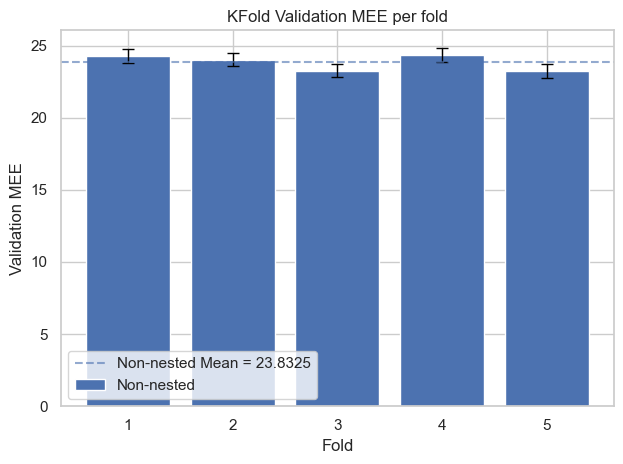

,TR_MEE,VL_MEE,Gap(TR-VL)
Fold,,,
1,23.501489,24.268613,0.767124
2,23.726949,24.034058,0.307109
3,23.537961,23.272942,-0.265019
4,23.237711,24.335816,1.098105
5,23.544201,23.251027,-0.293174
MEAN,23.509662,23.832491,0.322829
STD,0.175522,0.532767,0.617196


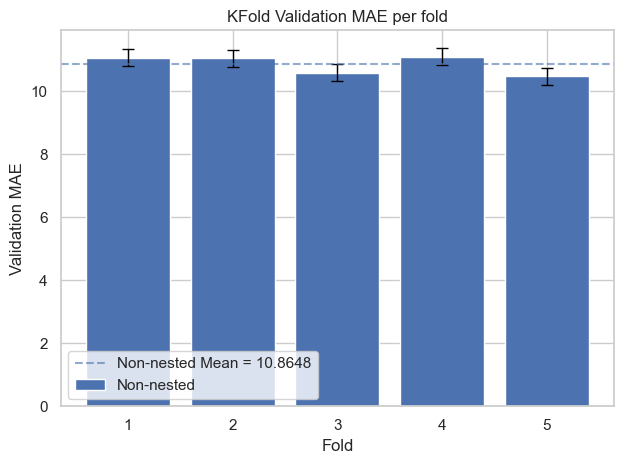

,TR_MAE,VL_MAE,Gap(TR-VL)
Fold,,,
1,10.716879,11.074195,0.357316
2,10.788794,11.056123,0.267329
3,10.695691,10.601578,-0.094113
4,10.571444,11.106181,0.534736
5,10.747702,10.486100,-0.261602
MEAN,10.704102,10.864835,0.160733
STD,0.082015,0.296401,0.329089


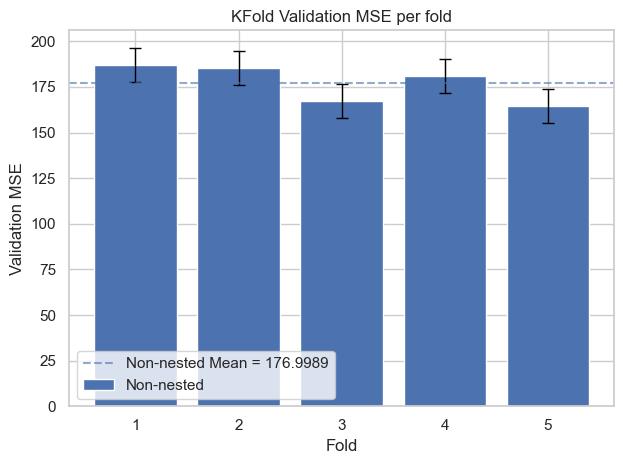

,TR_MSE,VL_MSE,Gap(TR-VL)
Fold,,,
1,171.696528,186.844119,15.147591
2,173.232811,185.416008,12.183196
3,174.717211,167.244556,-7.472654
4,172.102340,181.034348,8.932007
5,175.463858,164.455530,-11.008328
MEAN,173.442550,176.998912,3.556362
STD,1.627820,10.446821,11.952467


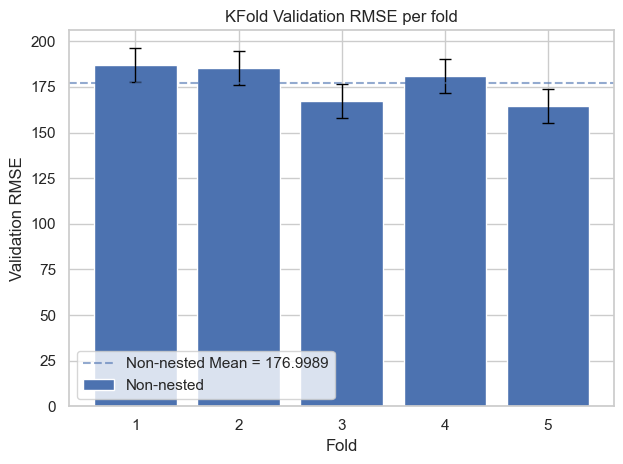

,TR_RMSE,VL_RMSE,Gap(TR-VL)
Fold,,,
1,171.696528,186.844119,15.147591
2,173.232811,185.416008,12.183196
3,174.717211,167.244556,-7.472654
4,172.102340,181.034348,8.932007
5,175.463858,164.455530,-11.008328
MEAN,173.442550,176.998912,3.556362
STD,1.627820,10.446821,11.952467


In [21]:
for metric in [MEE,MAE,MSE,RMSE]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [22]:
importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
#bootstrap_inner_train = copy.deepcopy(inner_train_params)
#bootstrap_inner_train.pop("split_strategy") # removed
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, bootstrap_params)

In [23]:
cr.aggregate_scores(bootstrap_scores)

,metric,mean,std,percentage
0,mee,24.83,0.99,3.97
1,mse,192.30,13.25,6.89
2,rmse,13.86,0.48,3.46
3,mae,11.26,0.49,4.33
4,r2,0.36,0.04,12.33


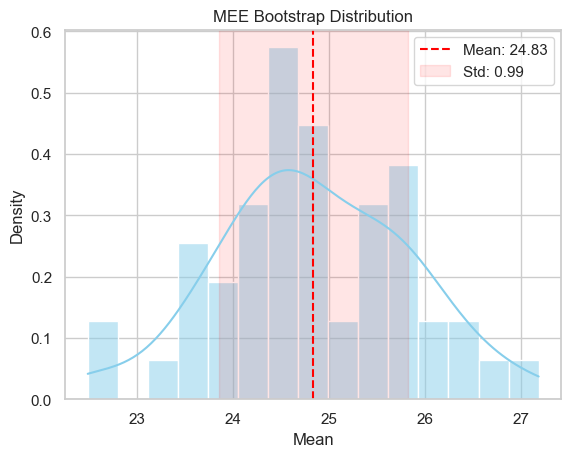

In [24]:
cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [25]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=scaler), # 0.1 = 10%
    **inner_train_params
)

Early stopping at epoch 137 (best VL mee loss: 22.2204)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 450
Validation      | samples: 50
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.00800621749027941, 'weight_decay': 1.813565767699133e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.7, 'patience': 30, 'threshold': 0.0001}
Early Stopping  | patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [26]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

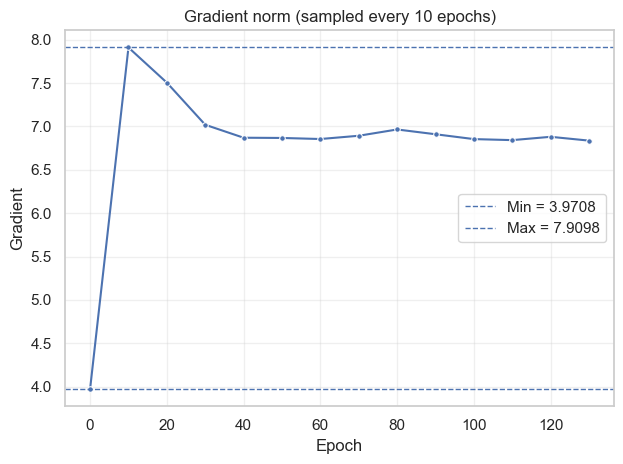

In [27]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

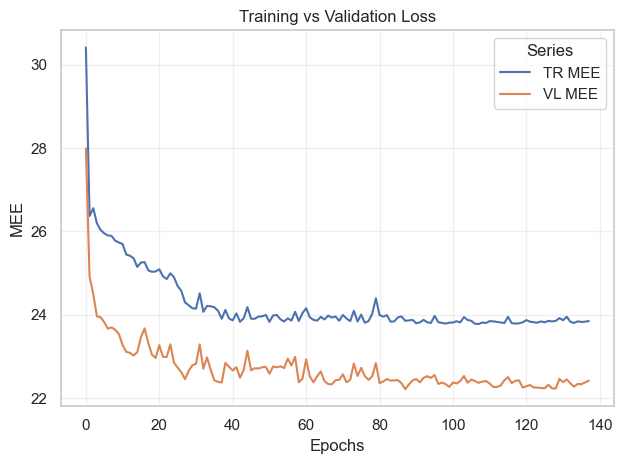

In [30]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

In [29]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

22.7169 ± 0.6426


<h3>Best Hyperparameters</h3>
<hr/>

In [32]:
print(inner_train_params)
print(final_hidden_layers)

{'epochs': 1000, 'batch_size': 64, 'scheduler_template': functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.7, patience=30, threshold=0.0001), 'optimizer_template': functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.00800621749027941, weight_decay=1.813565767699133e-05, betas=(0.95, 0.999)), 'loss_function': MEELoss(reduction='mean') - custom function, 'early_stopping_strategy': <nn_common.EarlyStoppingStrategy object at 0x121f9dfd0>}
[128, 64]
